# Final Project Pipeline Notebook

This cumulative notebook demonstrates the full Stage 04-16 pipeline and API behavior using project code.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

def find_project_root(start=Path.cwd()):
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import masked_config_status
print(masked_config_status())

{'project_root': '.', 'data_dir': 'data', 'raw_data_dir': 'data/raw', 'processed_data_dir': 'data/processed', 'reports_dir': 'reports', 'model_dir': 'model', 'docs_dir': 'docs', 'env_file_present': 'False'}


## Run the end-to-end pipeline

The command below downloads data, cleans it, builds features, creates EDA outputs, selects the model using development-period validation, evaluates on final test, and writes the stakeholder report.

In [2]:
from src.run_step import run_all

artifacts = run_all(start_date="2018-01-01", end_date="2026-08-26")
print(json.dumps(artifacts, indent=2, default=str))

2026-08-27 01:33:47,166 INFO Starting ingest step


2026-08-27 01:33:48,111 INFO Finished ingest step; saved sources=['manifest', 'sp500', 'treasury_10y', 'treasury_2y', 'vix']


2026-08-27 01:33:48,120 INFO Starting clean step


2026-08-27 01:33:48,253 INFO Finished clean step with 2173 rows


2026-08-27 01:33:48,255 INFO Starting features step


...

2026-08-27 01:33:58,752 INFO Finished model step with selected model=random_forest


2026-08-27 01:33:58,756 INFO Starting evaluate step


2026-08-27 01:34:09,600 INFO Finished evaluate step


2026-08-27 01:34:09,615 INFO Pipeline complete


{
  "ingest": {
    "sp500": "data\\raw\\sp500_yahoo.csv",
    "vix": "data\\raw\\vix_yahoo.csv",
    "treasury_10y": "data\\raw\\treasury_10y_fred.csv",
    "treasury_2y": "data\\raw\\treasury_2y_fred.csv",
    "manifest": "data\\raw\\raw_data_manifest.json"
  },
  "clean_rows": 2173,
  "feature_rows": 2148,
  "feature_count": 14,
  "eda": {
    "numeric_summary": "reports\\tables\\eda_numeric_summary.csv",
    "correlation_matrix": "reports\\tables\\eda_correlation_matrix.csv",
    "missingness": "reports\\tables\\eda_missingness.csv",
    "volatility_time_series": "reports\\figures\\eda_volatility_time_series.png",
    "vix_vs_future_vol": "reports\\figures\\eda_vix_vs_future_vol.png",
    "correlation_heatmap": "reports\\figures\\eda_correlation_heatmap.png"
  },
  "selected_model": "random_forest",
  "metrics": [
    {
      "model": "naive_last_5d_realized_vol",
      "role": "external_benchmark",
      "MAE": 0.0038548789743183425,
      "RMSE": 0.0063417627376447195,
      "R2"

## Inspect model-selection and final-test evidence

In [3]:
validation = pd.read_csv(PROJECT_ROOT / "reports/tables/model_validation_metrics.csv")
test = pd.read_csv(PROJECT_ROOT / "reports/tables/model_test_metrics.csv")
assumption = pd.read_csv(PROJECT_ROOT / "reports/tables/assumption_sensitivity.csv")
regime = pd.read_csv(PROJECT_ROOT / "reports/tables/regime_subgroup_metrics.csv")
display(validation.round(6))
display(test.round(6))
display(assumption.round(6))
display(regime.round(6))

,model,validation_MAE,validation_RMSE,validation_R2,validation_MAE_std,validation_RMSE_std,folds,selection_rank
0,random_forest,0.004477,0.006297,-0.219457,0.001911,0.003551,5,1
1,ridge,0.005718,0.009238,-0.973302,0.003874,0.009158,5,2
2,linear_regression,0.006063,0.010320,-1.310949,0.004425,0.011332,5,3


,model,role,MAE,RMSE,R2,MAE_improvement_vs_naive,RMSE_improvement_vs_naive
0,naive_last_5d_realized_vol,external_benchmark,0.003855,0.006342,-0.175610,0.000000,0.000000
1,random_forest,selected_by_development_validation,0.003566,0.006571,-0.262133,0.074879,-0.036146


,scenario,model,feature_count,train_rows,test_rows,test_start,test_end,MAE,RMSE,bias,delta_MAE_vs_baseline,delta_RMSE_vs_baseline,interpretation
0,"Baseline: selected model, full feature set, fu...",random_forest,14,1713,430,2024-11-29,2026-08-19,0.003566,0.006571,-0.001063,0.000000,0.000000,"Prediction holds if all approved market, volat..."
1,No Treasury/yield information,random_forest,10,1713,430,2024-11-29,2026-08-19,0.003271,0.006459,-0.000381,-0.000295,-0.000112,Tests sensitivity to losing interest-rate leve...
2,Shorter training history: 2020 onward,random_forest,14,1231,430,2024-11-29,2026-08-19,0.003410,0.006496,-0.000587,-0.000157,-0.000075,Tests whether older market regimes are helping...


,subgroup,n,selected_MAE,selected_RMSE,selected_bias,naive_MAE,MAE_improvement_vs_naive
0,All final-test observations,430,0.003566,0.006571,-0.001063,0.003855,0.074879
1,Low/normal VIX regime,366,0.002715,0.004224,-0.000545,0.003308,0.179420
2,High VIX regime,64,0.008437,0.013714,-0.004024,0.006982,-0.208398
3,High realized-volatility regime,85,0.006646,0.012012,-0.002659,0.007612,0.126952


## Display key stakeholder charts

actual_vs_predicted_volatility.png


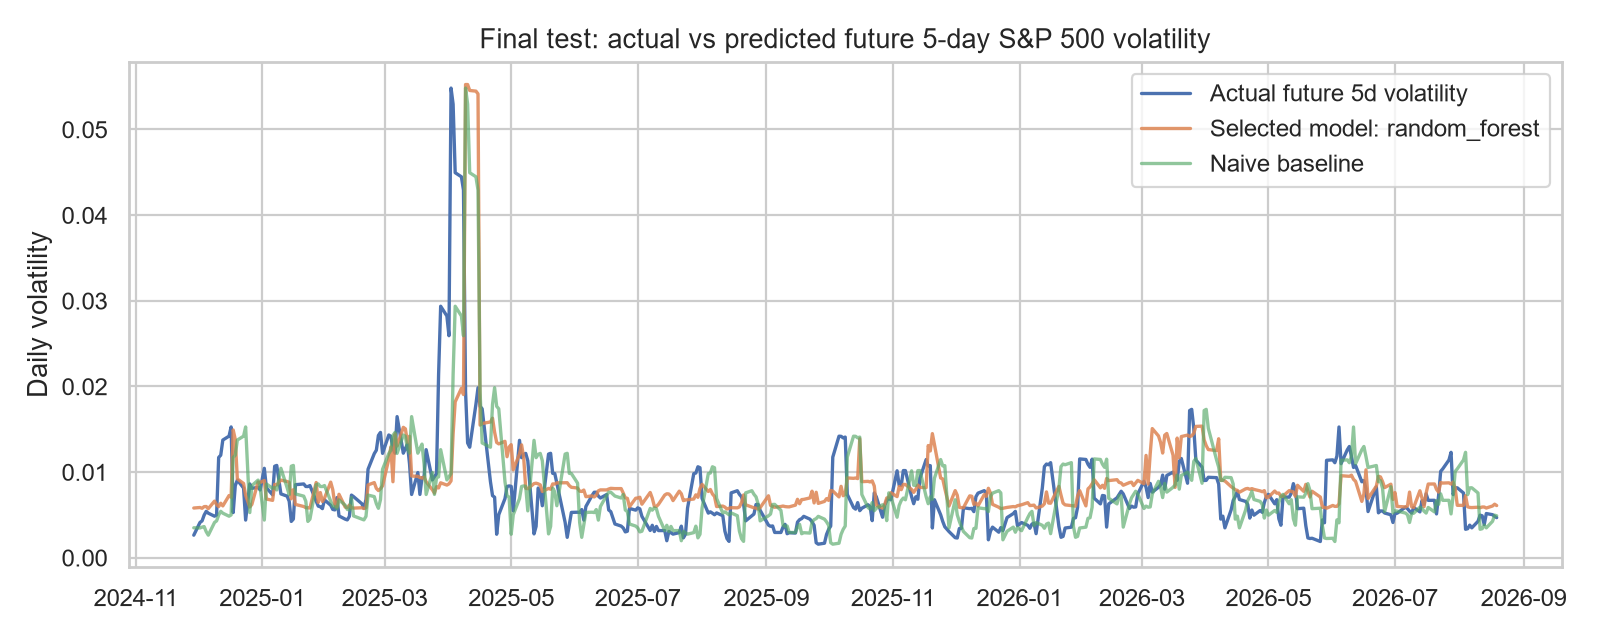

model_validation_comparison.png


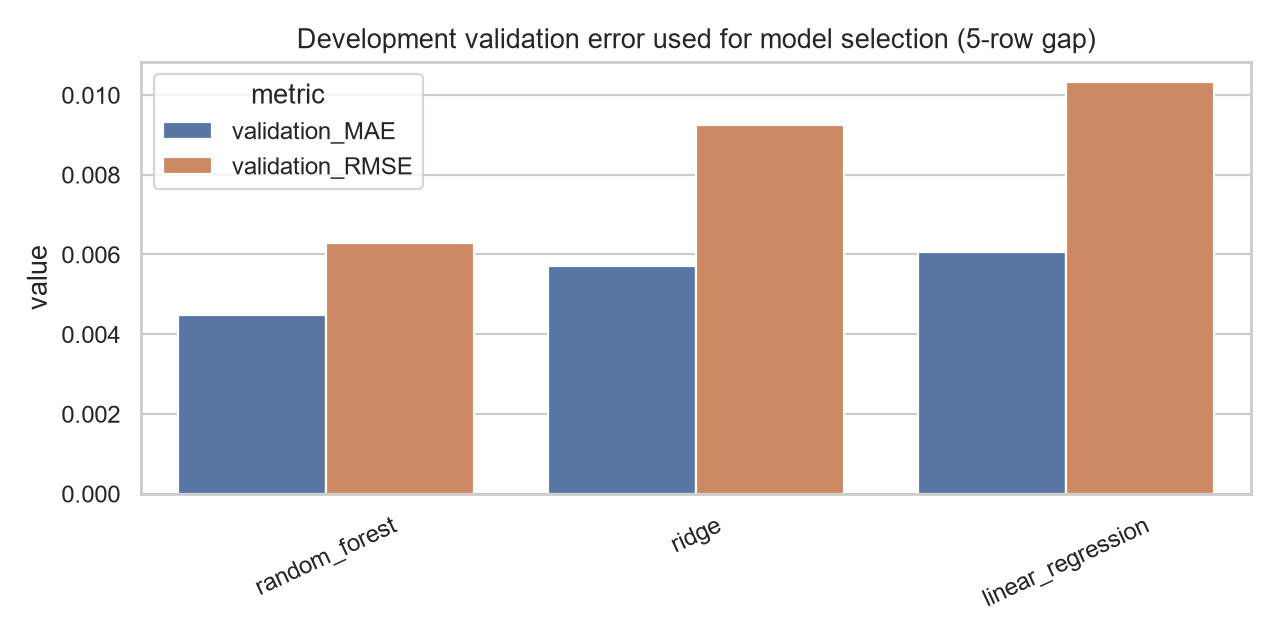

assumption_sensitivity.png


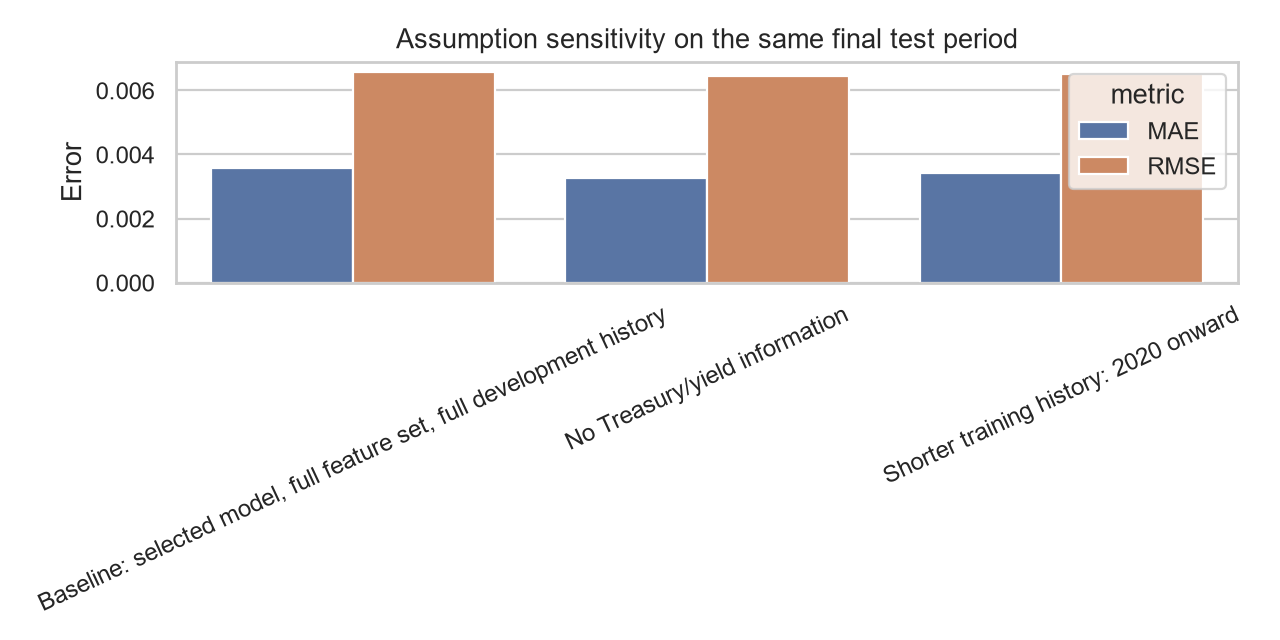

scenario_mae_by_regime.png


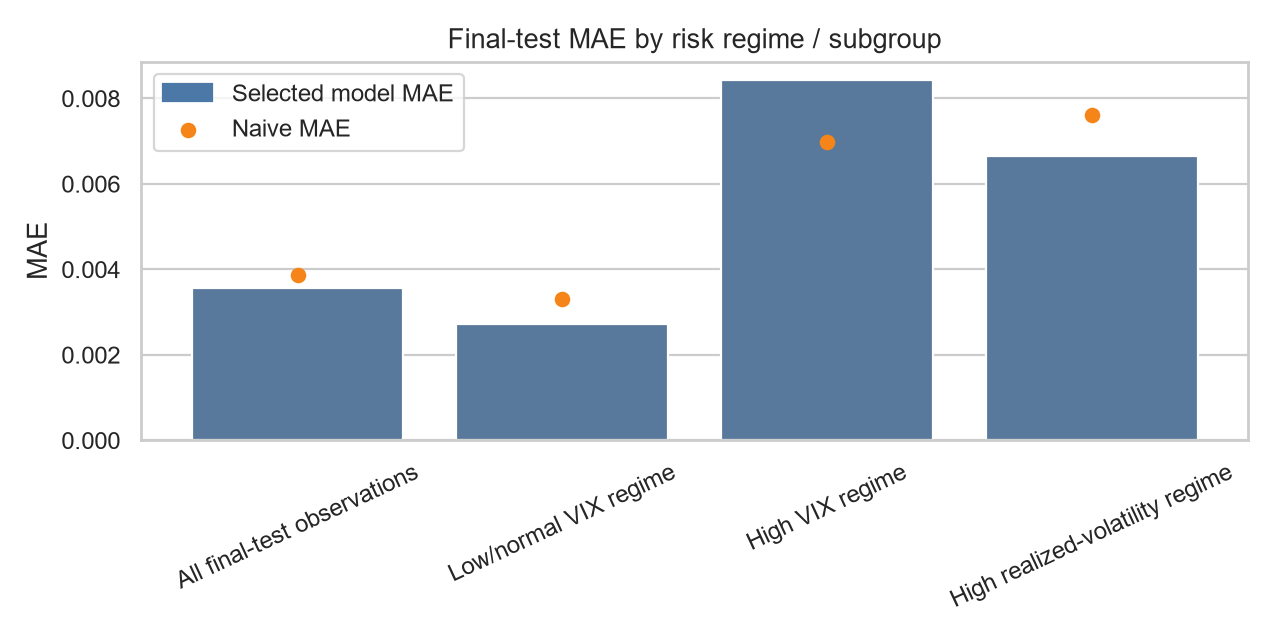

In [4]:
for figure in [
    "actual_vs_predicted_volatility.png",
    "model_validation_comparison.png",
    "assumption_sensitivity.png",
    "scenario_mae_by_regime.png",
]:
    print(figure)
    display(Image(filename=str(PROJECT_ROOT / "reports/figures" / figure)))

## Productization evidence: Flask API

The API loads the saved model once at startup. This notebook uses Flask's test client to show `/health`, `/features`, a valid `/predict`, and an intentionally invalid `/predict` returning HTTP 400 JSON.

In [5]:
import app as volatility_api

client = volatility_api.app.test_client()
health_response = client.get("/health")
features_response = client.get("/features")
feature_columns = features_response.get_json()["feature_columns"]
latest_features = pd.read_csv(PROJECT_ROOT / "data/processed/model_ready_volatility.csv").iloc[-1][feature_columns].astype(float).to_dict()
valid_response = client.post("/predict", json={"features": latest_features})
invalid_response = client.post("/predict", json={"features": [1, 2]})

print({"endpoint": "/health", "status_code": health_response.status_code, "json": health_response.get_json()})
print({"endpoint": "/features", "status_code": features_response.status_code, "feature_count": len(feature_columns)})
print({"endpoint": "/predict valid", "status_code": valid_response.status_code, "json": valid_response.get_json()})
print({"endpoint": "/predict invalid", "status_code": invalid_response.status_code, "json": invalid_response.get_json()})

{'endpoint': '/health', 'status_code': 200, 'json': {'model': 'random_forest', 'status': 'ok', 'target': 'future_5d_realized_volatility'}}
{'endpoint': '/features', 'status_code': 200, 'feature_count': 14}
{'endpoint': '/predict valid', 'status_code': 200, 'json': {'model': 'random_forest', 'prediction': 0.006073940225583303}}
{'endpoint': '/predict invalid', 'status_code': 400, 'json': {'error': "'features' must contain exactly 14 values."}}


## Final interpretation

The pipeline is reproducible and all artifacts are generated from project code. The selected model is chosen by development-period validation only. Final test results are mixed: average absolute error improves versus naive, while RMSE does not. This limitation is documented for the stakeholder because the tool should support risk judgment, not replace it.